In [1]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt


import seaborn as sns

In [2]:
df = pd.read_csv("placement.csv")

df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


# Steps before Model Building 

## pre-process + EDA + Feature Selection 

## Extract Input and Output Columns 

## Scaling The Values - Normalization,Std 

## Train the Test split

## Train The Model

## Evalute the Model/ Model Selection -- Best Algorith Selection 

## Deploy The Model on  Site 

In [3]:
# Pre-processing - we just remobve the unnamed calumn which is extra 

df = df.iloc[:,1:]

In [4]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


<Axes: xlabel='cgpa', ylabel='iq'>

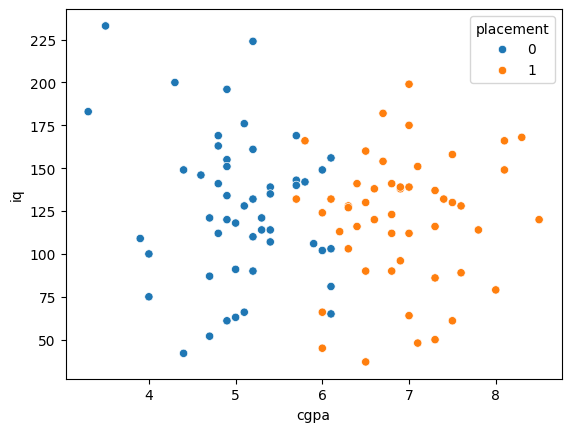

In [5]:
sns.scatterplot(df , x = "cgpa"  , y = "iq" , hue = "placement")

In [6]:
# extracting the input and output Column 

df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [7]:
x = df.iloc[:,0:2]

y = df.iloc[:,-1:]

In [8]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [9]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [10]:
# Train test split 

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.1)

In [11]:
x_train

,cgpa,iq
68,4.0,75.0
1,5.9,106.0
17,3.3,183.0
66,6.9,96.0
42,7.6,89.0
...,...,...
69,8.5,120.0
91,7.5,158.0
79,6.5,90.0
96,4.4,42.0


In [12]:
x_test

,cgpa,iq
94,4.7,52.0
52,7.0,175.0
22,4.9,120.0
56,6.1,65.0
18,4.0,100.0
76,4.9,155.0
0,6.8,123.0
55,7.8,114.0
73,4.9,61.0
58,8.0,79.0


In [13]:
y_train

,placement
68,0
1,0
17,0
66,1
42,1
...,...
69,1
91,1
79,1
96,0


In [14]:
y_test

,placement
94,0
52,1
22,0
56,0
18,0
76,0
0,1
55,1
73,0
58,1


In [15]:
from sklearn.preprocessing import StandardScaler # 0 se 1 ke beach me scale kr dega yeh 


In [16]:
scaler = StandardScaler()

In [17]:
x_train = scaler.fit_transform(x_train)

In [18]:
x_train.shape

(90, 2)

In [19]:
x_test = scaler.fit_transform(x_test)

x_test

array([[-0.89866628, -1.34970881],
       [ 0.80954235,  1.8185008 ],
       [-0.7501264 ,  0.40182171],
       [ 0.14111289, -1.01485738],
       [-1.41855586, -0.11333433],
       [-0.7501264 ,  1.30334476],
       [ 0.66100247,  0.47909511],
       [ 1.40370187,  0.2472749 ],
       [-0.7501264 , -1.11788859],
       [ 1.55224175, -0.65424816]])

# Model Training

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
clf = LogisticRegression()

clf.fit(x_train,y_train)

C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [22]:
# Evaluate the Model 
print('Actual Data:' ,y_train )
y_pred=clf.predict(x_test)

Actual Data:     placement
68          0
1           0
17          0
66          1
42          1
..        ...
69          1
91          1
79          1
96          0
34          0

[90 rows x 1 columns]


In [23]:
from sklearn.metrics import accuracy_score

In [24]:
accuracy_score(y_test,y_pred)

0.9

In [25]:
# Decision Boundry

!pip install mlxtend


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

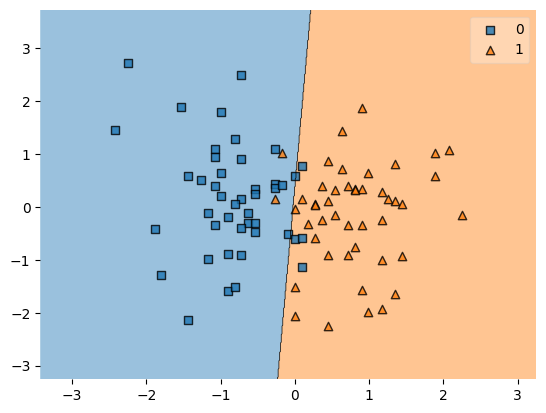

In [27]:
plot_decision_regions(x_train, y_train.values.reshape(90,), clf=clf, legend=1)

In [28]:
import pickle

pickle.dump(clf,open("model.pkl","wb"))

In [ ]:
\j